# SENDAs Update 2010-2024 (Prediction, step 2.7, external case-mix validation of mortality, convenios 3 and 5)


<style type="text/css">
.showopt {
background-color: #004c93; color: #FFFFFF; width: 100px; height: 20px; text-align: center; vertical-align: middle !important; float: right; font-family: sans-serif; border-radius: 8px;
}
.showopt:hover {
background-color: #dfe4f2;
color: #004c93;
}
pre.plot {
background-color: white !important;
}
.tablelines table, .tablelines td, .tablelines th {
border: 1px solid black;
}
.centrado {
text-align: center;
}
.table.center {
margin-left:auto;
margin-right:auto;
}
/* https://vivekjaiskumar.medium.com/css-is-and-not-selector-17c942ec83f :is()*/
/* Applies to outputs that are not code other than R*/
pre {
overflow-x: auto !important;
}
pre code {
word-wrap: normal !important;
white-space: pre !important;
}
/*
pre:not(.sourceCode) {
white-space: nowrap !important;
}
*/
.sourceCode { /* Important gives precedence */
font-size: 10px !important;
line-height: 50% !important;
}
body{ /* Normal */
text-align: justify;
}
.superbigimage{
overflow-y:scroll;
height:350px;
white-space: nowrap;
overflow-x: auto;
width:100%;
}
.superbigimage img{
overflow-y: scroll;
overflow-x: hidden;
}
.message { color:#446C6E; font-family: monospace;font-size: 10px; line-height: 110%; font-weight: bold;}
div.blue { background-color:#e6f0ff; border-radius: 5px; padding: 5px; text-align: justify;}
div.red { background-color:#e6bab1; border-radius: 5px; padding: 5px; text-align: justify;}
.pandoc-table { /* Should add !important; but it seems no necessary */
margin-left:auto; /* To center */
margin-right:auto;
border-collapse: collapse;
table-layout: auto;
font-size: 11px;
overflow-y: auto;
max-height:450px !important;
white-space: nowrap;
overflow-x: auto;
width:450px;
}
.pandoc-table th {/* header */
text-align: center !important;
font-size: 10px;
padding: 0px;
}
.pandoc-table td {
text-align: left !important;
font-size: 9px;
padding: 0px;
}
.pandoc-table caption {
text-align: left !important;
font-size: 11px !important;
}
.center-table {
text-align: left !important;
font-size: 9px;
overflow-y:scroll;
height:450px;
overflow-x: scroll;
}
.controlly{
overflow-y:scroll;
height:350px;
overflow-x: scroll;
}
/*2025-03-07*/
.callout-warning,
.callout-error,
.callout-message {
  font-size: 0.7rem !important;  /* Adjust this value as needed */
}
.alert, .message {
    font-size: 0.7em !important;
}
.alert.alert-warning,
.alert.alert-danger,
.message {
    font-size: 0.7em !important;
}
</style>


<style>
#| label: css-format
h1 {
    color: var(--heading-color);
    font-size: 2rem;
    margin-bottom: 1vh;
}
p {
  font-size: 1.1rem;
  line-height: 1.6rem;
}
a {
  color: var(--primary-color);
  text-decoration: none;
  border-bottom: 3px solid transparent;
  font-weight: bold;
  &:hover, &:focus {
      border-bottom: 3px solid currentColor;
  }
}
section {
  margin: 0 auto;
}
.post-meta {
  font-size: 1rem;
  font-style: italic;
  display: block;
  margin-bottom: 4vh;
  color: var(--secondary-color);
}
nav {
  display: flex;
  justify-content: flex-end;
  padding: 20px 0;
}
/*slider switch css */
.theme-switch-wrapper {
  display: flex;
  align-items: center;
  
  em {
    margin-left: 10px;
    font-size: 1rem;
  }
}
.theme-switch {
  display: inline-block;
  height: 34px;
  position: relative;
  width: 60px;
}
.theme-switch input {
  display:none;
}
.slider {
  background-color: #ccc;
  bottom: 0;
  cursor: pointer;
  left: 0;
  position: absolute;
  right: 0;
  top: 0;
  transition: .4s;
}
.slider:before {
  background-color: #fff;
  bottom: 4px;
  content: "";
  height: 26px;
  left: 4px;
  position: absolute;
  transition: .4s;
  width: 26px;
}
input:checked + .slider {
  background-color: #66bb6a;
}
input:checked + .slider:before {
  transform: translateX(26px);
}
.slider.round {
  border-radius: 34px;
}
.slider.round:before {
  border-radius: 50%;
}
</style>


<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">


In [1]:
#| label: setup
#| results: "hold"
#renv falls back to copying rather than symlinking, which is evidently very slow in this configuration.
renv::settings$use.cache(FALSE)
#only use explicit dependencies (in DESCRIPTION)
renv::settings$snapshot.type("implicit")
#check if rstools is installed
if(Sys.info()["sysname"]=="Windows"){
try(installr::install.Rtools(check_r_update=F))
}
check_quarto_version <- function(required = "1.7.29", comparator = c("ge","gt","le","lt","eq")) {
  comparator <- match.arg(comparator)
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req     <- package_version(required)
  ok <- switch(comparator,
               ge = current >= req,
               gt = current >  req,
               le = current <= req,
               lt = current <  req,
               eq = current == req)
  if (!ok) {
    stop(sprintf("Quarto version check failed: need %s %s (installed: %s).",
                 comparator, required, current), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge") 
#change repository to CL
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos=r)
})
if(!require(pacman)){install.packages("pacman");require(pacman)}
if(!require(pak)){install.packages("pak");require(pak)}
pacman::p_unlock(lib.loc = .libPaths()) #para no tener problemas reinstalando paquetes
if(Sys.info()["sysname"]=="Windows"){
if (getRversion() != "4.4.1") { stop("Requires R version 4.4.1; Actual: ", getRversion()) }
}
#check docker
check_docker_running <- function() {
  # Try running 'docker info' to check if Docker is running
  system("docker info", intern = TRUE, ignore.stderr = TRUE)
}
if(Sys.info()["sysname"]=="Windows"){
  install_docker <- function() {
    # Open the Docker Desktop download page in the browser for installation
    browseURL("https://www.docker.com/products/docker-desktop")
  }
  # Main logic
  if (inherits(try(check_docker_running(), silent = TRUE), "try-error")) {
    liftr::install_docker()
  } else {
    message("Docker is running.")
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#PACKAGES#######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
unlink("*_cache", recursive=T)
pak::pak_sitrep()
# pak::sysreqs_check_installed(unique(unlist(paks)))
#pak::lockfile_create(unique(unlist(paks)),  "dependencies_duplicates24.lock", dependencies=T)
#pak::lockfile_install("dependencies_duplicates24.lock")
#https://rdrr.io/cran/pak/man/faq.html
#pak::cache_delete()
library(tidytable)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(riskRegression)
library(prodlim)
library(caret)
library(ggplot2)
library(dplyr)
library(survex)
library(pec)
library(future)
library(future.apply)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)
library(knitr)
if (!requireNamespace("ipeval", quietly = TRUE)) {
  renv::install("ipeval")
}
#flexsurv
#if(!require(compareCstat)){install.pacakges("compareCstat")}
# library(shapr)#https://norskregnesentral.github.io/shapr/
# library(SemiMarkov)#https://www.degruyterbrill.com/document/doi/10.1515/ijb-2020-0083/html?lang=en
# #https://www.jclinepi.com/article/S0895-4356(24)00142-2/fulltext
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 3. Activate polars code completion (safe to try even if it fails)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
#try(polars_code_completion_activate())
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 4. BPMN from GitHub (not on CRAN, so install via devtools if missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
if (!requireNamespace("bpmn", quietly = TRUE)) {
  devtools::install_github("bergant/bpmn")
}
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 5. PhantomJS Check (use webshot if PhantomJS is missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# if (!webshot::is_phantomjs_installed()) {
#   webshot::install_phantomjs()
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
pander::panderOptions('big.mark', ',')
pander::panderOptions('decimal.mark', '.')

#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)

tnr<- "Times New Roman" 

options(scipen=2) #display numbers rather scientific number

# ── Helpers ────────────────────────────────────────────────────────────
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
find_latest_file <- function(project_root, prefix) {
  # Get all files matching the pattern
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.csv$")
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern))
  }
  # Extract timestamps from filenames (format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    timestamp_str <- matches[[1]][length(matches[[1]])]
    return(timestamp_str)
  }
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in filenames")
  }
  # Sort by timestamp (descending) and return the latest
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}

Installing package into ‘C:/Users/andre/AppData/Local/R/win-library/4.4’
(as ‘lib’ is unspecified)


trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.4/pkgbuild_1.4.8.zip'
Content type 'application/zip' length 211084 bytes (206 KB)
downloaded 206 KB



package ‘pkgbuild’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\andre\AppData\Local\Temp\RtmpmUVIgH\downloaded_packages
Loading required package: pkgbuild
No need to install Rtools - You've got the relevant version of Rtools installed


Warning message:
package ‘pkgbuild’ was built under R version 4.4.3 


Loading required package: pacman


...

Warning message:
package ‘pec’ was built under R version 4.4.3 



Attaching package: ‘future’

The following object is masked from ‘package:survival’:

    cluster

The following object is masked from ‘package:caret’:

    cluster



Warning message:
package ‘future.apply’ was built under R version 4.4.3 


Registered S3 method overwritten by 'broom':
  method        from          
  nobs.multinom riskRegression

Attaching package: ‘mice’

The following objects are masked from ‘package:tidytable’:

    complete, filter

The following object is masked from ‘package:stats’:

    filter

The following objects are masked from ‘package:base’:

    cbind, rbind


Attaching package: ‘tidyr’

The following objects are masked from ‘package:tidytable’:

    complete, crossing, drop_na, expand, expand_grid, extract, fill,
    nest, nesting, pivot_longer, pivot_wider, replace_na, separate,
    separate_longer_delim, separate_rows, separate_wider_delim,
    separate_wider_regex, tribble, uncount, unite, unnest,
    unnest_longer, unnest_wider

Loading required package: foreach
Loading required package: grid


Warning message:
package ‘survAUC’ was built under R version 4.4.3 
Warning message:
package ‘knitr’ was built under R version 4.4.3 


In [2]:
#| label: define-project-root-and-paths
root <- here::here()
project_root <- gsub("/cons$", "", root)
data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")
out_dir  <- file.path(project_root, "cons", "_out")

In [3]:
#| label: set-global-options
#| message: false

options(future.globals.maxSize = 10 * 1024^3)

In [4]:
project_root <- gsub("/cons$", "", getwd())

# External (case-mix) validation: post-discharge mortality on SENDA convenios 3 and 5

The mortality model (best_perf2, the SHAP-reduced cause-specific Cox of time from discharge to all-cause death) was developed on convenio 1 (general population, plus women's plans), adults 18-64, admitted 2010-2020. Here it is applied **without refitting** to two independent SENDA agreements the model never saw:

- **Convenio 3** -- population experiencing homelessness (adults).
- **Convenio 5** -- adolescent population (only the adult fraction, 18-29, is in scope).

The model is fit on the full development cohort (5 MICE imputations) and predictions are pooled across imputations (mean linear predictor for ranking, mean survival for IBS and calibration). Patients already in the development cohort are excluded, so there is no overlap. The DEIS mortality registry covers deaths through 2020, so this is a same-era case-mix validation (not temporal) and follow-up is censored at 2020-12-31, the same death-ascertainment window the model was developed on.

Raw C3/C5 variables are recoded to the development schema and labels. The plan-type stratum is mapped to the nearest development modality (C3 to pg-pr; C5 pai-ia to pg-pai, pr-ia to pg-pr); Uno's C-index does not depend on the baseline hazard, so it transports regardless, while IBS and calibration borrow the development baseline of the mapped stratum. Convenio 5 reports discrimination only because too few post-discharge deaths accrue for stable calibration.

In [5]:
#| label: extval-source-engines
#| message: false
project_root <- gsub("/cons$", "", getwd())
source(file.path(project_root, "cons/_alt_scripts/extval_death_01_build_cohort.R"))
source(file.path(project_root, "cons/_alt_scripts/run_extval_death.R"))
source(file.path(project_root, "cons/_alt_scripts/extval_death_02_table1_smd.R"))

# DEIS mortality registry covers 2008-2020 -> follow-up censored 2020-12-31.
# C3/C5 are discharged on/before 2020-12-31 with follow-up up to ~79 months, so the
# 60-month (5-year) horizon IS supported (unlike the readmission temporal cohort).
EVAL_TIMES <- c(3, 6, 12, 36, 60)
CAL_TIMES  <- c(6, 12, 36, 60)
B_BOOT     <- 1000L

# knitr::kable returned as a cell value is not auto-displayed by the Jupyter/Quarto
# jupyter engine (knitr_kable has no display method). Emit it as markdown so it
# renders as a real table; fall back to print() if IRdisplay is unavailable.
show_kable <- function(k) {
  if (requireNamespace("IRdisplay", quietly = TRUE))
    IRdisplay::display_markdown(paste(as.character(k), collapse = "\n"))
  else print(k)
}
# Same idea for an htmltools/browsable object (the SMD table).
show_html <- function(x) {
  if (requireNamespace("IRdisplay", quietly = TRUE))
    IRdisplay::display_html(as.character(htmltools::as.tags(x)))
  else print(x)
}

## Frozen mortality model, development fit, cohorts and bootstrap

`run_extval_death()` builds the development fit (cached), recodes and dummifies the C3 and C5 cohorts, applies the frozen model, computes discrimination, IBS and calibration with bootstrap 95% CIs, derives the common-support matched subsamples, and assembles the development-vs-external SMD table. The full result object is saved to `data/20241015_out/pred27/`.

In [6]:
#| label: extval-run
#| message: false
# Parallel backend for the bootstrap (sequential worker startup avoids the
# 'workers failed to connect' timeout on Drive paths).
if (requireNamespace("future", quietly = TRUE) && !inherits(future::plan(), "multisession")) {
  options(parallelly.makeNodePSOCK.setup_strategy = "sequential")
  options(parallelly.makeNodePSOCK.connectTimeout = 600)
  future::plan(future::multisession, workers = min(8L, max(1L, parallelly::availableCores() %/% 2L)))
}
options(future.globals.maxSize = 10 * 1024^3)

res <- run_extval_death(eval_times = EVAL_TIMES, cal_times = CAL_TIMES,
                        B = B_BOOT, seed = 2125L, parallel = TRUE, save = TRUE, verbose = TRUE)
cat(sprintf("Convenio 3: n=%d, deaths=%d (%.1f%%); matched n=%d.\n",
            res$C3$n, res$C3$n_events, 100*res$C3$n_events/res$C3$n, res$C3$match$n))
cat(sprintf("Convenio 5: n=%d, deaths=%d (%.2f%%); matched n=%d.\n",
            res$C5$n, res$C5$n_events, 100*res$C5$n_events/res$C5$n, res$C5$match$n))

Loading cached dev (full) dummified: g:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/_val_inputs/extval_dev_full_dummified.rds 
Fitted mortality model on 5 dev imputations.

================= C3 =================
[C3] raw: rows=3,077 patients=2,155
1. exclude development-cohort patients: removed 1,087 rows; 1,990 remain
2. adults 18-64: 1,807 ; with discharge on/before 2020-12-31: 720
3. first episode per patient: 648

=== C3 DEATH COHORT FLOW ===
                                 step    n
                             raw rows 3077
                         raw patients 2155
 after excluding development patients 1990
                         adults 18-64 1807
         with discharge <= 2020-12-31  720
    first episode per patient (FINAL)  648
   deaths (post-discharge, <= censor)   82
                             censored  566
Complete-case on mortality predictors: 648 -> 629 rows (dropped 19, 2.9%)
Common-support match: dev PS support [0.000, 0.203]; kept 628 of 629 external (99.8

## Cohort construction

In [7]:
#| label: extval-flow-c3
show_kable(knitr::kable(res$C3$flow, "markdown",
  caption = "Convenio 3 (population experiencing homelessness): mortality cohort construction (deaths censored 2020-12-31)"))



Table: Convenio 3 (population experiencing homelessness): mortality cohort construction (deaths censored 2020-12-31)

|step                                 |    n|
|:------------------------------------|----:|
|raw rows                             | 3077|
|raw patients                         | 2155|
|after excluding development patients | 1990|
|adults 18-64                         | 1807|
|with discharge <= 2020-12-31         |  720|
|first episode per patient (FINAL)    |  648|
|deaths (post-discharge, <= censor)   |   82|
|censored                             |  566|


In [8]:
#| label: extval-flow-c5
show_kable(knitr::kable(res$C5$flow, "markdown",
  caption = "Convenio 5 (adolescent population, adults 18-29): mortality cohort construction (deaths censored 2020-12-31)"))



Table: Convenio 5 (adolescent population, adults 18-29): mortality cohort construction (deaths censored 2020-12-31)

|step                                 |     n|
|:------------------------------------|-----:|
|raw rows                             | 12440|
|raw patients                         |  8883|
|after excluding development patients | 11726|
|adults 18-64                         |  8789|
|with discharge <= 2020-12-31         |  4597|
|first episode per patient (FINAL)    |  3986|
|deaths (post-discharge, <= censor)   |    21|
|censored                             |  3965|


## Discrimination (Uno's C-index) and prediction error (IBS)

Each convenio is evaluated on the full external cohort and on two subsamples matched to convenio 1 on the model covariates: a common-support propensity trim (keeps every external patient within the development propensity range) and a stricter 1:1 nearest-neighbour propensity match without replacement (caliper 0.2 SD of the logit propensity). Convenio 5 reports the global Uno's C-index only: with about 16 post-discharge deaths the horizon-specific concordance and IBS are unstable, so they are suppressed.

In [9]:
#| label: extval-discrimination
fmt_ci_d <- function(ev, boot, metric, time, bkey, dig = 3) {
  e <- ev$summary$Value[ev$summary$Metric == metric & ev$summary$Time == time]
  if (!length(e) || all(is.na(e))) return("\u2014")
  e <- e[1]; if (is.na(e)) return("\u2014")
  r <- boot[boot$metric == bkey, ]
  if (!nrow(r) || is.na(r$lo[1])) return(sprintf(paste0("%.", dig, "f"), e))
  sprintf(paste0("%.", dig, "f (%.", dig, "f, %.", dig, "f)"), e, r$lo[1], r$hi[1])
}
disc_row <- function(label, ev, boot, do_ibs, global_only = FALSE) {
  data.frame(
    Cohort = label,
    `Uno's C, global` = fmt_ci_d(ev, boot, "Uno's C-Index", "Global", "c_global"),
    `C, 12 mo` = if (global_only) "\u2014" else fmt_ci_d(ev, boot, "Uno's C-Index", "12", "c_12"),
    `C, 36 mo` = if (global_only) "\u2014" else fmt_ci_d(ev, boot, "Uno's C-Index", "36", "c_36"),
    `C, 60 mo` = if (global_only) "\u2014" else fmt_ci_d(ev, boot, "Uno's C-Index", "60", "c_60"),
    `IBS, global` = if (do_ibs) fmt_ci_d(ev, boot, "IBS", "Global", "ibs_global") else "\u2014",
    check.names = FALSE, stringsAsFactors = FALSE)
}
disc <- rbind(
  disc_row("Convenio 3 (full)",           res$C3$eval,       res$C3$boot,       TRUE,  FALSE),
  disc_row("Convenio 3 (common support)", res$C3$match$eval, res$C3$match$boot, TRUE,  FALSE),
  disc_row("Convenio 3 (1:1 NN)",         res$C3$nn$eval,    res$C3$nn$boot,    TRUE,  FALSE),
  disc_row("Convenio 5 (full)",           res$C5$eval,       res$C5$boot,       FALSE, TRUE),
  disc_row("Convenio 5 (common support)", res$C5$match$eval, res$C5$match$boot, FALSE, TRUE),
  disc_row("Convenio 5 (1:1 NN)",         res$C5$nn$eval,    res$C5$nn$boot,    FALSE, TRUE))
show_kable(knitr::kable(disc, "markdown",
  caption = "External mortality discrimination: Uno's C-index and IBS (bootstrap 95% CI; frozen model, dev-fit MI-pooled). Two matched subsamples vs convenio 1: common-support PS trim and 1:1 nearest-neighbour PS match (caliper 0.2 SD)."))



Table: External mortality discrimination: Uno's C-index and IBS (bootstrap 95% CI; frozen model, dev-fit MI-pooled). Two matched subsamples vs convenio 1: common-support PS trim and 1:1 nearest-neighbour PS match (caliper 0.2 SD).

|Cohort                      |Uno's C, global      |C, 12 mo             |C, 36 mo             |C, 60 mo             |IBS, global          |
|:---------------------------|:--------------------|:--------------------|:--------------------|:--------------------|:--------------------|
|Convenio 3 (full)           |0.710 (0.649, 0.764) |0.701 (0.600, 0.795) |0.743 (0.675, 0.800) |0.703 (0.642, 0.762) |0.146 (0.145, 0.298) |
|Convenio 3 (common support) |0.710 (0.645, 0.767) |0.701 (0.600, 0.794) |0.743 (0.677, 0.800) |0.704 (0.640, 0.763) |0.147 (0.145, 0.298) |
|Convenio 3 (1:1 NN)         |0.710 (0.649, 0.764) |0.701 (0.600, 0.795) |0.743 (0.675, 0.800) |0.703 (0.642, 0.762) |0.146 (0.145, 0.298) |
|Convenio 5 (full)           |0.412 (0.229, 0.578) |—        

Warning message:
`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


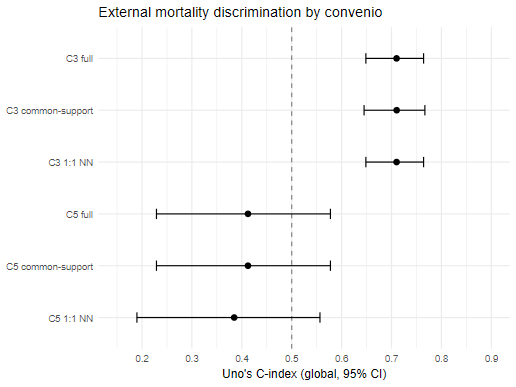

`height` was translated to `width`.

In [10]:
#| label: extval-cindex-plot
#| fig-width: 7
#| fig-height: 3.2
gv <- function(boot, k) { r <- boot[boot$metric == k, ]; if (nrow(r)) c(r$lo[1], r$hi[1]) else c(NA, NA) }
labs <- c("C3 full", "C3 common-support", "C3 1:1 NN", "C5 full", "C5 common-support", "C5 1:1 NN")
cidf <- data.frame(
  cohort = factor(labs, levels = rev(labs)),
  c  = c(res$C3$eval$summary$Value[1], res$C3$match$eval$summary$Value[1], res$C3$nn$eval$summary$Value[1],
         res$C5$eval$summary$Value[1], res$C5$match$eval$summary$Value[1], res$C5$nn$eval$summary$Value[1]),
  lo = c(gv(res$C3$boot, "c_global")[1], gv(res$C3$match$boot, "c_global")[1], gv(res$C3$nn$boot, "c_global")[1],
         gv(res$C5$boot, "c_global")[1], gv(res$C5$match$boot, "c_global")[1], gv(res$C5$nn$boot, "c_global")[1]),
  hi = c(gv(res$C3$boot, "c_global")[2], gv(res$C3$match$boot, "c_global")[2], gv(res$C3$nn$boot, "c_global")[2],
         gv(res$C5$boot, "c_global")[2], gv(res$C5$match$boot, "c_global")[2], gv(res$C5$nn$boot, "c_global")[2]))
if (requireNamespace("ggplot2", quietly = TRUE)) {
  library(ggplot2)
  ggplot(cidf, aes(c, cohort)) +
    geom_vline(xintercept = 0.5, linetype = 2, color = "grey50") +
    geom_errorbarh(aes(xmin = lo, xmax = hi), height = 0.2) +
    geom_point(size = 2.4) +
    scale_x_continuous(limits = c(0.15, 0.9), breaks = seq(0.2, 0.9, 0.1)) +
    labs(x = "Uno's C-index (global, 95% CI)", y = NULL,
         title = "External mortality discrimination by convenio") +
    theme_minimal(base_size = 12)
}

## Calibration (convenio 3)

Predicted mortality risk from the frozen Cox versus Kaplan-Meier observed risk (readmission and administrative end as censoring), in risk deciles. The integrated calibration index (ICI, the loess-smoothed mean absolute predicted-minus-observed difference) is the primary calibration metric; the expected:observed ratio is reported alongside. Convenio 5 is omitted (too few deaths for stable calibration).

In [11]:
#| label: extval-calibration-table
cal_tab <- function(cal, boot, label) {
  if (is.null(cal)) return(NULL)
  do.call(rbind, lapply(CAL_TIMES, function(h) {
    ps <- cal$pooled_summary[cal$pooled_summary$time_months == h, ]
    ir <- boot[boot$metric == paste0("ici_", h), ]
    er <- boot[boot$metric == paste0("eo_", h), ]
    data.frame(Cohort = label, `Horizon, mo` = h,
      `ICI (95% CI)` = sprintf("%.3f (%.3f, %.3f)", ps$ici_mean, ir$lo[1], ir$hi[1]),
      ECE = sprintf("%.3f", ps$ece_mean),
      `E:O (95% CI)` = sprintf("%.2f (%.2f, %.2f)", ps$eo_mean, er$lo[1], er$hi[1]),
      `Predicted` = sprintf("%.3f", ps$mean_pred),
      `Observed (KM)` = sprintf("%.3f", ps$observed),
      check.names = FALSE, stringsAsFactors = FALSE)
  }))
}
calib <- rbind(cal_tab(res$C3$cal, res$C3$boot, "Convenio 3 (full)"),
               cal_tab(res$C3$match$cal, res$C3$match$boot, "Convenio 3 (common support)"),
               cal_tab(res$C3$nn$cal, res$C3$nn$boot, "Convenio 3 (1:1 NN)"))
show_kable(knitr::kable(calib, "markdown",
  caption = "External mortality calibration, convenio 3: ICI (primary), ECE, expected:observed ratio, predicted vs observed (Kaplan-Meier). ICI is the integrated absolute predicted-minus-observed difference; E:O < 1 indicates under-prediction at that horizon."))



Table: External mortality calibration, convenio 3: ICI (primary), ECE, expected:observed ratio, predicted vs observed (Kaplan-Meier). ICI is the integrated absolute predicted-minus-observed difference; E:O < 1 indicates under-prediction at that horizon.

|Cohort                      | Horizon, mo|ICI (95% CI)         |ECE   |E:O (95% CI)      |Predicted |Observed (KM) |
|:---------------------------|-----------:|:--------------------|:-----|:-----------------|:---------|:-------------|
|Convenio 3 (full)           |           6|0.022 (0.011, 0.037) |0.025 |0.38 (0.27, 0.60) |0.013     |0.035         |
|Convenio 3 (full)           |          12|0.028 (0.014, 0.047) |0.028 |0.46 (0.34, 0.66) |0.024     |0.053         |
|Convenio 3 (full)           |          36|0.024 (0.013, 0.051) |0.028 |0.78 (0.63, 1.03) |0.080     |0.102         |
|Convenio 3 (full)           |          60|0.050 (0.027, 0.090) |0.047 |0.70 (0.58, 0.90) |0.128     |0.181         |
|Convenio 3 (common support) |     

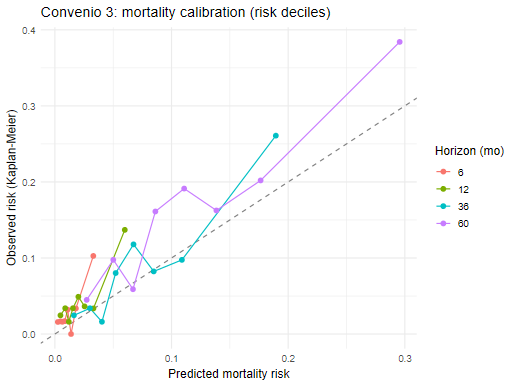

In [12]:
#| label: extval-calibration-curve
#| fig-width: 6.5
#| fig-height: 4.5
cc <- res$C3$cal$calibration_curves
if (!is.null(cc) && nrow(cc) && requireNamespace("ggplot2", quietly = TRUE)) {
  library(ggplot2)
  ggplot(cc, aes(mean_predicted, observed, color = factor(time_months))) +
    geom_abline(slope = 1, intercept = 0, linetype = 2, color = "grey50") +
    geom_line() + geom_point(size = 2) +
    labs(x = "Predicted mortality risk", y = "Observed risk (Kaplan-Meier)",
         color = "Horizon (mo)", title = "Convenio 3: mortality calibration (risk deciles)") +
    theme_minimal(base_size = 12)
} else {
  cat("No calibration curve available.\n")
}

## Development versus external convenios: standardized mean differences

Covariate distribution of the development cohort (convenio 1, training-set Table 1) versus convenios 3 and 5, in the full external cohort and in each matched subsample (CS = common-support trim; 1:1 NN = nearest-neighbour propensity match). Only the variables used by the mortality model (plus age and sex) are shown. |SMD| >= 0.10 is highlighted. Note that common-support trimming removes only off-support patients and so barely changes the SMDs; the 1:1 NN match is the variant that can actually reduce residual imbalance.

In [13]:
#| label: extval-smd-table
#| results: asis
#| message: false
show_html(extval_death_smd_browsable(res$smd))

Variable,Level,"Development C1 (n=70,521)",C3 (n=629),SMD,C3 (CS) (n=628),SMD,C3 (1:1 NN) (n=629),SMD,"C5 (n=3,235)",SMD,"C5 (CS) (n=3,235)",SMD,"C5 (1:1 NN) (n=2,879)",SMD
"Age at admission, mean (SD)",,35.7 (10.5),47.0 (10.0),1.103,47.0 (10.0),1.101,47.0 (10.0),1.103,21.7 (2.1),1.848,21.7 (2.1),1.848,22.0 (2.0),1.809
Female sex (yes),,25.6%,64 (10.2%),0.411,64 (10.2%),0.410,64 (10.2%),0.411,1175 (36.3%),0.233,1175 (36.3%),0.233,992 (34.5%),0.194
Primary substance at admission,Cocaine paste,37.8%,256 (40.7%),0.059,255 (40.6%),0.057,256 (40.7%),0.059,283 (8.7%),0.732,283 (8.7%),0.732,283 (9.8%),0.695
,Alcohol,34.0%,330 (52.5%),0.379,330 (52.5%),0.381,330 (52.5%),0.379,345 (10.7%),0.584,345 (10.7%),0.584,335 (11.6%),0.553
,Cocaine hydrochloride,19.6%,19 (3.0%),0.542,19 (3.0%),0.542,19 (3.0%),0.542,248 (7.7%),0.353,248 (7.7%),0.353,222 (7.7%),0.352
,Marijuana,6.8%,17 (2.7%),0.194,17 (2.7%),0.193,17 (2.7%),0.194,2074 (64.1%),1.496,2074 (64.1%),1.496,1794 (62.3%),1.438
,Others,1.8%,7 (1.1%),0.057,7 (1.1%),0.057,7 (1.1%),0.057,285 (8.8%),0.317,285 (8.8%),0.317,245 (8.5%),0.307
Substance of onset,Alcohol,58.9%,370 (58.8%),0.002,370 (58.9%),0.000,370 (58.8%),0.002,753 (23.3%),0.777,753 (23.3%),0.777,753 (26.2%),0.702
,Marijuana,29.9%,156 (24.8%),0.115,155 (24.7%),0.117,156 (24.8%),0.115,2244 (69.4%),0.859,2244 (69.4%),0.859,1911 (66.4%),0.784
,Cocaine paste,4.8%,52 (8.3%),0.141,52 (8.3%),0.141,52 (8.3%),0.141,30 (0.9%),0.234,30 (0.9%),0.234,30 (1.0%),0.225


## Feasibility of a case-mix-balanced subsample

Common-support and 1:1 nearest-neighbour matching retain almost the entire external cohort and therefore do not reduce the covariate imbalance: convenios 3 and 5 lie inside convenio 1's covariate support, so the difference is one of density, not support. A distributionally balanced comparison would instead require reweighting the external cohort to the convenio 1 covariate distribution (inverse-probability / overlap weights; the same target as cardinality matching or coarsened exact matching). The effective sample size of that reweighting, ESS = (sum w)^2 / sum(w^2) with ATT weights w = (1 - e)/e, and the effective number of deaths it leaves, indicate whether such a balanced comparison is even powered. When ESS and effective deaths collapse, no balanced subsample is reportable and the full-cohort estimate stands as the transportability result under a different case-mix.

In [14]:
#| label: extval-feasibility
feas_tab <- do.call(rbind, lapply(list(res$C3, res$C5), function(r) data.frame(
  Convenio = r$convenio, `n (complete-case)` = r$feasibility$n, Deaths = r$feasibility$events,
  `IPW effective n` = round(r$feasibility$ess),
  `Effective deaths` = round(r$feasibility$eff_events, 1),
  `Max weighted SMD` = round(r$feasibility$max_weighted_smd, 2),
  check.names = FALSE, stringsAsFactors = FALSE)))
show_kable(knitr::kable(feas_tab, "markdown",
  caption = "Feasibility of a convenio-1-balanced external subsample: IPW (ATT) effective sample size and effective deaths when standardizing each convenio to the convenio 1 covariate distribution. A collapsed effective sample (or residual max weighted SMD > 0.1) means cardinality matching / CEM / IPW cannot yield a usable balanced cohort for this endpoint, so the full-cohort estimate is reported instead."))



Table: Feasibility of a convenio-1-balanced external subsample: IPW (ATT) effective sample size and effective deaths when standardizing each convenio to the convenio 1 covariate distribution. A collapsed effective sample (or residual max weighted SMD > 0.1) means cardinality matching / CEM / IPW cannot yield a usable balanced cohort for this endpoint, so the full-cohort estimate is reported instead.

|Convenio | n (complete-case)| Deaths| IPW effective n| Effective deaths| Max weighted SMD|
|:--------|-----------------:|------:|---------------:|----------------:|----------------:|
|C3       |               629|     79|              53|              2.7|             0.24|
|C5       |              3235|     16|              19|              0.1|             1.43|


## Save

In [15]:
#| label: extval-save
out_dir <- file.path(project_root, "data", "20241015_out", "pred27")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
utils::write.csv(disc,  file.path(out_dir, "extval_death_discrimination.csv"), row.names = FALSE)
if (!is.null(calib)) utils::write.csv(calib, file.path(out_dir, "extval_death_calibration.csv"), row.names = FALSE)
utils::write.csv(res$smd, file.path(out_dir, "extval_death_smd_table1.csv"), row.names = FALSE)
cat("Saved CSVs and result RDS to", out_dir, "\n")

Saved CSVs and result RDS to g:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred27 


## Session info

In [16]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true

message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", getwd()))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: C:\Users\andre\AppData\Local/R/win-library/4.4
Date: 2026-06-29 15:57:34.426199
Editor context: g:/My Drive/Alvacast/SISTRAT 2023/cons
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpmUVIgH/fileaa1c6784572f -V' had status 1


1,backports,1.5.0,CRAN (R 4.4.1)
2,base64enc,0.1-3,CRAN (R 4.4.1)
3,boot,1.3-31,CRAN (R 4.4.1)
4,bpmn,0.1.0,Github (bergant/bpmn@628d3efaa27544c221b2fd7f1895301a63b70c49)
5,broom,1.0.10,CRAN (R 4.4.3)
6,cachem,1.1.0,CRAN (R 4.4.1)
7,caret,7.0-1,CRAN (R 4.4.1)
8,checkmate,2.3.3,CRAN (R 4.4.3)
9,class,7.3-22,CRAN (R 4.4.1)
10,cli,3.6.4,CRAN (R 4.4.1)
11,cluster,2.1.8.1,CRAN (R 4.4.1)
